# 📚 Does Your Research Paper have an Impact? A Citation Prediction Pipeline 📝

Research papers accumulate citations over time, but can their future scholarly visibility be estimated using metadata available at publication?

This notebook builds a complete machine learning workflow using scholarly metadata collected from the **OpenAlex API**. It moves from data collection and cleaning to exploratory analysis, regression modeling, tuning, explainability, error analysis, and prediction for a new paper.

### ✨ What You Will Build

- A reusable OpenAlex data collection pipeline
- A cleaned research-paper metadata dataset
- Citation-focused exploratory visualizations
- Multiple regression models for citation prediction
- A tuned LightGBM model using Optuna
- SHAP-based model explanations
- Error analysis for overpredicted and underpredicted papers
- A reusable function for predicting citations for new paper-like inputs
- CSV, Parquet, image, model, and Markdown report outputs

> 🎯 **Project Goal:** Build an interpretable and reusable citation prediction workflow rather than treating model accuracy as the only outcome.

![GIF](https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExNDAydzF5MWRxbDAwcnNoNjJrNGdyM2Z1bzV1dDVyeWF1M2U0aGd3dCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/VbnUQpnihPSIgIXuZv/giphy.gif)


---


<div align="left">

## If you find this notebook interesting, please **Upvote**! 👍🏻


 💬 **Comments, suggestions, and feedback are always welcome.**

</div>


---

## 🗺️ Notebook Roadmap

| Stage | What Happens |
|---|---|
| **1. Setup** | Install packages, import libraries, and define configuration |
| **2. Collect** | Retrieve scholarly metadata from OpenAlex |
| **3. Prepare** | Clean records and engineer model-ready features |
| **4. Explore** | Examine citation, year, venue, field, and access patterns |
| **5. Model** | Train, compare, and tune regression algorithms |
| **6. Explain** | Interpret the selected model with SHAP |
| **7. Diagnose** | Study prediction errors and difficult cases |
| **8. Reuse** | Predict citations for new inputs and export results |

> ✅ **Recommended Use:** Run the notebook from top to bottom after adjusting the configuration values.


## 1. 📦 Installing Required Packages

This section installs the external Python packages required for the citation prediction pipeline.

The notebook uses:

- `requests-cache` for caching OpenAlex API responses
- `pyarrow` for saving the dataset in Parquet format
- `xgboost`, `lightgbm`, and `catboost` for advanced regression models
- `shap` for model explainability
- `optuna` for hyperparameter tuning
- `tqdm` for progress bars
- `tabulate` for creating Markdown-style summary tables

These packages make the notebook suitable for a complete Kaggle-style machine learning workflow.

> 💡 **Pro Tip:** Run this cell once at the start of a fresh Kaggle or Colab session. If the environment already contains these packages, the installation step may finish quickly.


In [1]:
# ============================================================
# 1. Install Required Packages
# ============================================================

import sys
import subprocess

packages = [
    "requests-cache",
    "pyarrow",
    "xgboost",
    "lightgbm",
    "catboost",
    "shap",
    "optuna",
    "tabulate",
    "tqdm"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Packages installed successfully.")


Packages installed successfully.


## 2. 🧰 Importing Libraries

This section imports the libraries used for data collection, processing, modeling, visualization, and reporting.

The notebook uses `pandas` and `numpy` for data handling, `requests` for API calls, `matplotlib` for visualization, `scikit-learn` for preprocessing and baseline modeling, and advanced gradient boosting libraries for improved regression performance.

> 🧭 **Notebook Guide:** Libraries are grouped by purpose so that data collection, preprocessing, modeling, visualization, and explainability remain easy to follow.


In [2]:
# ============================================================
# 2. Import Libraries
# ============================================================

import os
import re
import time
import json
import math
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, List, Optional

import requests
import requests_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import shap
import optuna

warnings.filterwarnings("ignore")

## 3. ⚙️ Configuration

This section defines the main project settings.

The configuration includes:

- Output directory for Colab or Kaggle
- OpenAlex API settings
- Search query for collecting research papers
- Publication year range
- Maximum number of papers to collect
- Request delay and retry settings
- Output file names for datasets, plots, and reports

The search query and year range can be modified to create datasets for different academic fields such as artificial intelligence, public health, marketing, cybersecurity, or information systems.

> ✏️ **Make It Your Own:** Change `SEARCH_QUERY`, `START_YEAR`, `END_YEAR`, and `MAX_PAPERS` to build a citation dataset for another research field or time period.


In [3]:
# ============================================================
# 3. Configuration
# ============================================================

# Works both in Kaggle and Colab
if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working")
else:
    OUTPUT_DIR = Path("/content")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# OpenAlex recommends identifying requests with a contact email.
# Use a project contact email before publishing publicly.
CONTACT_EMAIL = "contact@example.com"

BASE_URL = "https://api.openalex.org/works"

# Topic or field query.
# Examples: "machine learning", "artificial intelligence", "public health", "marketing", "cybersecurity"
SEARCH_QUERY = "machine learning"

START_YEAR = 2015
END_YEAR = 2025

# Alter the number according to need
MAX_PAPERS = 500

PER_PAGE = 200
REQUEST_DELAY = 0.15
MAX_RETRIES = 5

CURRENT_YEAR = datetime.now().year

PROJECT_NAME = "research_paper_citation_prediction"
OUTPUT_CSV = OUTPUT_DIR / f"{PROJECT_NAME}_{START_YEAR}_{END_YEAR}.csv"
OUTPUT_PARQUET = OUTPUT_DIR / f"{PROJECT_NAME}_{START_YEAR}_{END_YEAR}.parquet"
SUMMARY_REPORT = OUTPUT_DIR / f"{PROJECT_NAME}_summary_report.md"

PLOT_CITATION_DISTRIBUTION = OUTPUT_DIR / "citation_distribution.png"
PLOT_LOG_CITATION_DISTRIBUTION = OUTPUT_DIR / "log_citation_distribution.png"
PLOT_PAPERS_BY_YEAR = OUTPUT_DIR / "papers_by_year.png"
PLOT_MEAN_CITATIONS_BY_YEAR = OUTPUT_DIR / "mean_citations_by_year.png"
PLOT_TOP_VENUES = OUTPUT_DIR / "top_venues.png"
PLOT_FIELD_CITATIONS = OUTPUT_DIR / "field_wise_citations.png"
PLOT_MODEL_COMPARISON = OUTPUT_DIR / "model_comparison.png"
PLOT_SHAP_SUMMARY = OUTPUT_DIR / "shap_summary.png"

print("Output directory:", OUTPUT_DIR)
print("Search query:", SEARCH_QUERY)
print("Year range:", START_YEAR, "to", END_YEAR)
print("Maximum papers:", MAX_PAPERS)

Output directory: /content
Search query: machine learning
Year range: 2015 to 2025
Maximum papers: 500


## 4. 📝 Logging Setup

This section configures logging for the notebook.

Logging helps monitor the data collection and modeling process. It shows important information such as API progress, number of collected papers, cleaning status, and any errors that occur during execution.

> 👀 **Why This Matters:** Logging makes long API and modeling workflows easier to monitor than a series of disconnected print statements.


In [4]:
# ============================================================
# 4. Logging Setup
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger(__name__)

## 5. 🌐 API Session with Caching

This section creates a cached API session for OpenAlex requests.

Caching is useful because it avoids repeatedly calling the same API endpoints when the notebook is rerun. This improves efficiency, reduces waiting time, and makes the workflow more reliable during development.

A User-Agent is also added to identify the project when making API requests.

> ⚡ **Pro Tip:** Cached responses reduce repeated API calls when the notebook is rerun, which saves time and is more considerate of the OpenAlex service.


In [5]:
# ============================================================
# 5. API Session with Caching
# ============================================================

session = requests_cache.CachedSession(
    cache_name=str(OUTPUT_DIR / "openalex_cache"),
    backend="sqlite",
    expire_after=60 * 60 * 24 * 7
)

session.headers.update({
    "User-Agent": f"CitationPredictionProject/1.0 (mailto:{CONTACT_EMAIL})"
})

## 6. 🧩 Helper Functions

This section defines reusable helper functions used throughout the notebook.

The helper functions support:

- Robust API requests
- Abstract reconstruction from OpenAlex inverted indexes
- Text cleaning
- Word counting
- Safe dictionary value extraction

OpenAlex stores abstracts as inverted indexes, so the notebook reconstructs them into readable text before using them for feature engineering and text modeling.

> 🧩 **Behind the Scenes:** These utilities keep the main workflow readable by separating repeated tasks such as text cleaning, abstract reconstruction, and safe value extraction.


In [6]:
# ============================================================
# 6. Helper Functions
# ============================================================

def openalex_get(params: Dict[str, Any]) -> Dict[str, Any]:
    """
    Make a robust GET request to the OpenAlex Works API.

    Parameters
    ----------
    params : dict
        API query parameters.

    Returns
    -------
    dict
        JSON response from OpenAlex.
    """
    for attempt in range(MAX_RETRIES):
        try:
            time.sleep(REQUEST_DELAY)

            response = session.get(
                BASE_URL,
                params=params,
                timeout=40
            )

            if response.status_code == 200:
                return response.json()

            if response.status_code in [429, 500, 502, 503, 504]:
                wait = min(30, 2 ** attempt)
                logger.warning(
                    "HTTP %s. Retrying in %s seconds.",
                    response.status_code,
                    wait
                )
                time.sleep(wait)
                continue

            raise RuntimeError(
                f"OpenAlex API error {response.status_code}: {response.text[:300]}"
            )

        except requests.exceptions.RequestException as error:
            wait = min(30, 2 ** attempt)
            logger.warning("Network error: %s. Retrying in %s seconds.", error, wait)
            time.sleep(wait)

    raise RuntimeError("Failed after multiple retries.")


def reconstruct_abstract(abstract_inverted_index: Optional[Dict[str, List[int]]]) -> str:
    """
    Reconstruct abstract text from OpenAlex abstract_inverted_index.

    OpenAlex stores abstracts as inverted indexes rather than plain text.
    This function converts the inverted index back into readable text.
    """
    if not abstract_inverted_index:
        return ""

    position_to_word = {}

    for word, positions in abstract_inverted_index.items():
        for position in positions:
            position_to_word[position] = word

    if not position_to_word:
        return ""

    words = [
        position_to_word[position]
        for position in sorted(position_to_word.keys())
    ]

    return " ".join(words)


def clean_text(text: str) -> str:
    """
    Basic text cleaning for titles and abstracts.
    """
    if not isinstance(text, str):
        return ""

    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


def count_words(text: str) -> int:
    """
    Count words in a text field.
    """
    if not isinstance(text, str) or not text.strip():
        return 0

    return len(text.split())


def safe_get(dictionary: Optional[Dict[str, Any]], key: str, default=None):
    """
    Safely retrieve a value from a dictionary.
    """
    if not isinstance(dictionary, dict):
        return default

    return dictionary.get(key, default)

## 7. 📚 Data Collection from OpenAlex

This section collects scholarly paper metadata from the OpenAlex Works API.

The collection process searches for papers based on the selected query and publication year range. For each paper, the notebook extracts metadata such as title, abstract, publication year, citation count, journal, publisher, authorship details, institution details, open-access status, concepts, topics, and reference count.

Each record in the resulting dataset represents one research paper.

> 📌 **Data Note:** One row represents one research paper. The quality of later predictions depends on the completeness and consistency of the metadata returned by OpenAlex.


In [7]:
# ============================================================
# 7. Data Collection from OpenAlex
# ============================================================

def collect_openalex_papers() -> pd.DataFrame:
    """
    Collect paper metadata from OpenAlex Works API.

    Returns
    -------
    pandas.DataFrame
        Raw paper-level metadata.
    """
    rows = []
    cursor = "*"

    filters = (
        f"from_publication_date:{START_YEAR}-01-01,"
        f"to_publication_date:{END_YEAR}-12-31,"
        f"has_abstract:true"
    )

    logger.info("Starting OpenAlex data collection.")

    with tqdm(total=MAX_PAPERS, desc="Collecting papers") as progress_bar:
        while len(rows) < MAX_PAPERS:
            params = {
                "search": SEARCH_QUERY,
                "filter": filters,
                "per-page": PER_PAGE,
                "cursor": cursor,
                "mailto": CONTACT_EMAIL,
                "select": (
                    "id,doi,title,display_name,publication_year,publication_date,"
                    "cited_by_count,referenced_works_count,type,language,"
                    "abstract_inverted_index,authorships,primary_location,"
                    "open_access,concepts,topics"
                )
            }

            data = openalex_get(params)
            works = data.get("results", [])

            if not works:
                break

            for work in works:
                row = parse_openalex_work(work)
                rows.append(row)

                progress_bar.update(1)

                if len(rows) >= MAX_PAPERS:
                    break

            cursor = data.get("meta", {}).get("next_cursor")

            if not cursor:
                break

    logger.info("Collected %s paper records.", len(rows))

    return pd.DataFrame(rows)


def parse_openalex_work(work: Dict[str, Any]) -> Dict[str, Any]:
    """
    Convert one OpenAlex work object into a flat row.
    """
    abstract = reconstruct_abstract(work.get("abstract_inverted_index"))
    title = work.get("title") or work.get("display_name") or ""

    primary_location = work.get("primary_location") or {}
    source = primary_location.get("source") or {}

    open_access = work.get("open_access") or {}

    authorships = work.get("authorships") or []
    institutions = []
    countries = []
    author_names = []

    for authorship in authorships:
        author = authorship.get("author") or {}
        author_name = author.get("display_name")

        if author_name:
            author_names.append(author_name)

        for institution in authorship.get("institutions") or []:
            institution_name = institution.get("display_name")
            country_code = institution.get("country_code")

            if institution_name:
                institutions.append(institution_name)

            if country_code:
                countries.append(country_code)

    unique_institutions = sorted(set(institutions))
    unique_countries = sorted(set(countries))

    concepts = work.get("concepts") or []
    topics = work.get("topics") or []

    concept_names = [
        c.get("display_name", "")
        for c in concepts
        if c.get("display_name")
    ]

    topic_names = [
        t.get("display_name", "")
        for t in topics
        if t.get("display_name")
    ]

    keywords = concept_names[:10] if concept_names else topic_names[:10]

    main_field = ""
    if concepts:
        main_field = concepts[0].get("display_name", "")
    elif topics:
        main_field = topics[0].get("display_name", "")

    publication_year = work.get("publication_year")
    citation_count = work.get("cited_by_count", 0)

    return {
        "paper_id": work.get("id", ""),
        "doi": work.get("doi", ""),
        "paper_title": clean_text(title),
        "abstract": clean_text(abstract),
        "publication_year": publication_year,
        "publication_date": work.get("publication_date", ""),
        "paper_type": work.get("type", ""),
        "language": work.get("language", ""),
        "journal": source.get("display_name", ""),
        "publisher": source.get("host_organization_name", ""),
        "source_type": source.get("type", ""),
        "open_access": open_access.get("is_oa", False),
        "open_access_status": open_access.get("oa_status", ""),
        "field_of_study": main_field,
        "keywords": "; ".join(keywords),
        "number_of_authors": len(author_names),
        "authors": "; ".join(author_names[:20]),
        "first_author": author_names[0] if author_names else "",
        "institution": unique_institutions[0] if unique_institutions else "",
        "number_of_institutions": len(unique_institutions),
        "institution_country": unique_countries[0] if unique_countries else "",
        "international_collaboration": len(unique_countries) > 1,
        "references_count": work.get("referenced_works_count", 0),
        "citation_count": citation_count,
    }

## 8. 🧹 Data Cleaning and Feature Engineering

This section cleans the raw OpenAlex data and creates machine-learning-ready features.

The cleaning process removes duplicate papers, handles missing values, removes invalid records, standardizes text fields, and filters papers based on valid publication years and citation counts.

The feature engineering process creates important predictors such as:

- Title length
- Abstract length
- Keyword count
- Publication age
- Number of authors
- Number of institutions
- Reference count
- Open-access status
- International collaboration indicator
- Log-transformed citation count

The model uses `log1p(citation_count)` as the target because citation counts are highly skewed.

> 🛡️ **Modeling Checkpoint:** Citation counts are strongly skewed, so the notebook uses `log1p(citation_count)` to reduce the influence of extremely highly cited papers.


In [8]:
# ============================================================
# 8. Data Cleaning and Feature Engineering
# ============================================================

def clean_and_engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean raw paper metadata and create model-ready features.
    """
    logger.info("Starting data cleaning and feature engineering.")

    df = df.copy()

    # Remove duplicate papers
    df = df.drop_duplicates(subset=["paper_id"])

    # Prefer DOI-based deduplication when DOI exists
    doi_mask = df["doi"].notna() & (df["doi"].astype(str).str.strip() != "")
    df_with_doi = df[doi_mask].drop_duplicates(subset=["doi"])
    df_without_doi = df[~doi_mask]
    df = pd.concat([df_with_doi, df_without_doi], ignore_index=True)

    # Clean text fields
    df["paper_title"] = df["paper_title"].fillna("").apply(clean_text)
    df["abstract"] = df["abstract"].fillna("").apply(clean_text)
    df["journal"] = df["journal"].fillna("Unknown").replace("", "Unknown")
    df["publisher"] = df["publisher"].fillna("Unknown").replace("", "Unknown")
    df["field_of_study"] = df["field_of_study"].fillna("Unknown").replace("", "Unknown")
    df["institution"] = df["institution"].fillna("Unknown").replace("", "Unknown")
    df["institution_country"] = df["institution_country"].fillna("Unknown").replace("", "Unknown")
    df["source_type"] = df["source_type"].fillna("Unknown").replace("", "Unknown")
    df["open_access_status"] = df["open_access_status"].fillna("Unknown").replace("", "Unknown")
    df["keywords"] = df["keywords"].fillna("")

    # Remove missing abstracts and titles
    df = df[df["paper_title"].str.len() > 5]
    df = df[df["abstract"].str.len() > 30]

    # Numeric cleaning
    numeric_cols = [
        "publication_year",
        "number_of_authors",
        "number_of_institutions",
        "references_count",
        "citation_count"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["publication_year", "citation_count"])

    df = df[df["citation_count"] >= 0]
    df = df[df["publication_year"].between(START_YEAR, END_YEAR)]

    # Feature engineering
    df["title_length_words"] = df["paper_title"].apply(count_words)
    df["abstract_length_words"] = df["abstract"].apply(count_words)
    df["keyword_count"] = df["keywords"].apply(lambda x: len(x.split(";")) if x else 0)
    df["publication_age"] = CURRENT_YEAR - df["publication_year"] + 1
    df["citation_count_log"] = np.log1p(df["citation_count"])
    df["references_count_log"] = np.log1p(df["references_count"].fillna(0))
    df["number_of_authors_log"] = np.log1p(df["number_of_authors"].fillna(0))

    df["title_abstract_text"] = (
        df["paper_title"].fillna("") + " " + df["abstract"].fillna("")
    )

    df["open_access"] = df["open_access"].astype(bool).astype(int)
    df["international_collaboration"] = df["international_collaboration"].astype(bool).astype(int)

    # Citation rate is useful for EDA, not used as main target
    df["citation_rate_per_year"] = df["citation_count"] / df["publication_age"].replace(0, np.nan)

    df = df.reset_index(drop=True)

    logger.info("Cleaned dataset shape: %s", df.shape)

    return df

## 9. 🔎 Exploratory Data Analysis

This section explores the structure and patterns in the collected dataset.

The EDA includes:

- Dataset shape
- Full dataset preview
- Papers by publication year
- Mean citations by publication year
- Top publication venues
- Field-wise citation patterns
- Open-access citation summary
- Citation distribution
- Log citation distribution

These analyses help understand how citations vary across years, venues, fields, and access types before model training.

> 🔍 **Look Before You Model:** Pay special attention to the citation distribution, publication-year patterns, and venue concentration. These reveal imbalance and possible sources of bias.


In [9]:
# ============================================================
# 9. Exploratory Data Analysis
# ============================================================

def run_eda(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    """
    Create EDA summary tables and visualizations.
    """
    eda = {}

    eda["papers_by_year"] = (
        df.groupby("publication_year")
        .size()
        .reset_index(name="paper_count")
        .sort_values("publication_year")
    )

    eda["mean_citations_by_year"] = (
        df.groupby("publication_year")["citation_count"]
        .mean()
        .reset_index(name="mean_citation_count")
        .sort_values("publication_year")
    )

    eda["top_venues"] = (
        df.groupby("journal")
        .size()
        .reset_index(name="paper_count")
        .sort_values("paper_count", ascending=False)
        .head(15)
    )

    eda["field_citations"] = (
        df.groupby("field_of_study")["citation_count"]
        .mean()
        .reset_index(name="mean_citation_count")
        .sort_values("mean_citation_count", ascending=False)
        .head(15)
    )

    eda["open_access_summary"] = (
        df.groupby("open_access")["citation_count"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    return eda


def show_eda_outputs(df: pd.DataFrame, eda: Dict[str, pd.DataFrame]) -> None:
    """
    Display EDA tables and plots.
    """
    print("\n========== DATASET SHAPE ==========")
    print(df.shape)

    print("\n========== FULL DATASET ==========")
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_colwidth", 120)

    display(df)

    print("\n========== PAPERS BY YEAR ==========")
    display(eda["papers_by_year"])

    print("\n========== MEAN CITATIONS BY YEAR ==========")
    display(eda["mean_citations_by_year"])

    print("\n========== TOP VENUES ==========")
    display(eda["top_venues"])

    print("\n========== FIELD-WISE MEAN CITATIONS ==========")
    display(eda["field_citations"])

    print("\n========== OPEN ACCESS SUMMARY ==========")
    display(eda["open_access_summary"])

    # Citation distribution
    plt.figure(figsize=(10, 5))
    plt.hist(df["citation_count"], bins=50)
    plt.title("Citation Count Distribution")
    plt.xlabel("Citation Count")
    plt.ylabel("Number of Papers")
    plt.tight_layout()
    plt.savefig(PLOT_CITATION_DISTRIBUTION, dpi=300)
    plt.show()

    # Log citation distribution
    plt.figure(figsize=(10, 5))
    plt.hist(df["citation_count_log"], bins=50)
    plt.title("Log Citation Count Distribution")
    plt.xlabel("log(1 + Citation Count)")
    plt.ylabel("Number of Papers")
    plt.tight_layout()
    plt.savefig(PLOT_LOG_CITATION_DISTRIBUTION, dpi=300)
    plt.show()

    # Papers by year
    plt.figure(figsize=(10, 5))
    plt.bar(eda["papers_by_year"]["publication_year"], eda["papers_by_year"]["paper_count"])
    plt.title("Papers Collected by Publication Year")
    plt.xlabel("Publication Year")
    plt.ylabel("Number of Papers")
    plt.tight_layout()
    plt.savefig(PLOT_PAPERS_BY_YEAR, dpi=300)
    plt.show()

    # Mean citations by year
    plt.figure(figsize=(10, 5))
    plt.plot(
        eda["mean_citations_by_year"]["publication_year"],
        eda["mean_citations_by_year"]["mean_citation_count"],
        marker="o"
    )
    plt.title("Mean Citation Count by Publication Year")
    plt.xlabel("Publication Year")
    plt.ylabel("Mean Citation Count")
    plt.tight_layout()
    plt.savefig(PLOT_MEAN_CITATIONS_BY_YEAR, dpi=300)
    plt.show()

    # Top venues
    plt.figure(figsize=(10, 7))
    plt.barh(eda["top_venues"]["journal"], eda["top_venues"]["paper_count"])
    plt.gca().invert_yaxis()
    plt.title("Top Venues by Number of Papers")
    plt.xlabel("Number of Papers")
    plt.ylabel("Venue")
    plt.tight_layout()
    plt.savefig(PLOT_TOP_VENUES, dpi=300)
    plt.show()

    # Field-wise citations
    plt.figure(figsize=(10, 7))
    plt.barh(
        eda["field_citations"]["field_of_study"],
        eda["field_citations"]["mean_citation_count"]
    )
    plt.gca().invert_yaxis()
    plt.title("Top Fields by Mean Citation Count")
    plt.xlabel("Mean Citation Count")
    plt.ylabel("Field")
    plt.tight_layout()
    plt.savefig(PLOT_FIELD_CITATIONS, dpi=300)
    plt.show()

## 10. 🛠️ Modeling Preparation

This section prepares the dataset for machine learning.

The notebook separates the features and target variable, then defines preprocessing steps for numerical, categorical, and text features.

The preprocessing pipeline includes:

- Median imputation and scaling for numerical variables
- Most-frequent imputation and one-hot encoding for categorical variables
- TF-IDF vectorization for title and abstract text

A time-aware train-test split is used where possible. Papers published up to 2020 are used for training, while papers published after 2020 are used for testing. This helps reduce temporal leakage.

> ⏳ **Good Practice:** A time-aware split is more realistic than a purely random split because older papers have had more time to collect citations.


In [10]:
# ============================================================
# 10. Modeling Preparation
# ============================================================

def prepare_model_data(df: pd.DataFrame):
    """
    Prepare features and target for regression models.

    This corrected version avoids duplicate columns in the modeling DataFrame.
    """
    target_col = "citation_count_log"

    numeric_features = [
        "publication_year",
        "number_of_authors",
        "number_of_institutions",
        "references_count",
        "title_length_words",
        "abstract_length_words",
        "keyword_count",
        "publication_age",
        "open_access",
        "international_collaboration",
        "references_count_log",
        "number_of_authors_log"
    ]

    categorical_features = [
        "journal",
        "publisher",
        "field_of_study",
        "institution",
        "institution_country",
        "source_type",
        "open_access_status"
    ]

    text_feature = "title_abstract_text"

    feature_columns = numeric_features + categorical_features + [text_feature]

    # Keep only features and target.
    # Do not add publication_year again because it is already in numeric_features.
    model_df = df[feature_columns + [target_col]].copy()

    # Remove accidental duplicate columns if any exist.
    model_df = model_df.loc[:, ~model_df.columns.duplicated()]

    X = model_df[feature_columns].copy()
    y = model_df[target_col].copy()

    # Final safety check: remove duplicate columns from X.
    X = X.loc[:, ~X.columns.duplicated()]

    return X, y, numeric_features, categorical_features, text_feature


def create_preprocessor(
    numeric_features: List[str],
    categorical_features: List[str],
    text_feature: str
) -> ColumnTransformer:
    """
    Create preprocessing pipeline for numeric, categorical, and text features.
    """
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=50))
        ]
    )

    text_transformer = TfidfVectorizer(
        max_features=3000,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
            ("txt", text_transformer, text_feature)
        ],
        remainder="drop"
    )

    return preprocessor


def time_aware_split(df: pd.DataFrame, X: pd.DataFrame, y: pd.Series):
    """
    Create a time-aware train-test split.

    Papers up to 2020 are used for training.
    Papers after 2020 are used for testing.

    If the split becomes too small, it falls back to random split.
    """
    year_series = X["publication_year"]

    train_mask = year_series <= 2020
    test_mask = year_series > 2020

    if train_mask.sum() > 100 and test_mask.sum() > 100:
        X_train = X.loc[train_mask].copy()
        X_test = X.loc[test_mask].copy()
        y_train = y.loc[train_mask].copy()
        y_test = y.loc[test_mask].copy()
        split_type = "Time-aware split: train <= 2020, test > 2020"
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )
        split_type = "Random 80/20 split"

    return X_train, X_test, y_train, y_test, split_type

## 🎉 Milestone Reached: Data Is Ready

You have completed data collection, cleaning, feature engineering, exploratory analysis, and modeling preparation.

The next part moves into model training, tuning, explanation, and diagnosis.

> ☕ **Pause and Check:** Confirm that the dataset shape, missing-value handling, feature lists, and train-test split look sensible before training the models.

![GIF](https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExNnFpb3Foa2tjZW10YTV3NGU5NDdpOG80OHEybzQ1MzRtb29tY2M1OCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/LW6hZxaWkkWrK/giphy.gif)


## 11. 🤖 Model Training and Evaluation

This section trains and compares multiple regression models for citation prediction.

The models include:

- Linear Regression
- Ridge Regression
- Random Forest
- Extra Trees
- XGBoost
- LightGBM
- CatBoost

The models are evaluated using:

- MAE
- RMSE
- R² on the log-transformed target
- RMSLE

RMSLE is especially useful for citation prediction because citation counts are skewed and contain large differences between low-cited and highly cited papers.

> 📊 **Metric Tip:** No single metric tells the full story. Compare MAE and RMSE on the original scale, then use RMSLE and log-scale R² to judge relative prediction quality.


In [11]:
# ============================================================
# 11. Model Training and Evaluation
# ============================================================

def evaluate_predictions(y_true_log, y_pred_log) -> Dict[str, float]:
    """
    Evaluate model predictions on log target and original citation scale.
    """
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    y_pred = np.maximum(y_pred, 0)

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true_log, y_pred_log)
    rmsle = math.sqrt(mean_squared_error(y_true_log, y_pred_log))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2_log_target": r2,
        "RMSLE": rmsle
    }


def train_models(X_train, X_test, y_train, y_test, preprocessor):
    """
    Train multiple regression models and compare performance.

    This corrected version handles failed models safely.
    """
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(
            n_estimators=120,
            random_state=42,
            n_jobs=-1,
            max_depth=18
        ),
        "Extra Trees": ExtraTreesRegressor(
            n_estimators=120,
            random_state=42,
            n_jobs=-1,
            max_depth=18
        ),
        "XGBoost": XGBRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective="reg:squarederror",
            n_jobs=-1
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        "CatBoost": CatBoostRegressor(
            iterations=250,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False
        )
    }

    results = []
    fitted_pipelines = {}

    for model_name, model in models.items():
        print(f"\nTraining model: {model_name}")

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        try:
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            metrics = evaluate_predictions(y_test, y_pred)
            metrics["Model"] = model_name

            results.append(metrics)
            fitted_pipelines[model_name] = pipeline

            print(metrics)

        except Exception as error:
            print(f"Model failed: {model_name} | Error: {error}")

    if len(results) == 0:
        raise RuntimeError(
            "All models failed. Please check duplicate columns, missing values, or preprocessing configuration."
        )

    results_df = pd.DataFrame(results)

    expected_columns = [
        "Model",
        "MAE",
        "RMSE",
        "R2_log_target",
        "RMSLE"
    ]

    results_df = results_df[expected_columns].sort_values("RMSLE")

    return results_df, fitted_pipelines

## 12. 🎯 Hyperparameter Tuning with Optuna

This section uses Optuna to tune the LightGBM model.

Optuna is a modern hyperparameter optimization framework that searches for better model settings more efficiently than manual tuning or exhaustive grid search.

To keep the notebook suitable for Kaggle execution, only a limited number of trials is used. The tuned model is compared with the best untuned model before selecting the final model.

> 🎯 **Pro Tip:** Increase `n_trials` for a deeper search when runtime permits. A small value keeps the notebook practical for demonstration and Kaggle execution.


In [12]:
# ============================================================
# 12. Hyperparameter Tuning with Optuna
# ============================================================

def tune_lightgbm_with_optuna(X_train, X_test, y_train, y_test, preprocessor, n_trials=15):
    """
    Tune LightGBM using Optuna.

    A small number of trials is used to keep notebook runtime manageable.
    """
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
            "num_leaves": trial.suggest_int("num_leaves", 20, 80),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1
        }

        model = LGBMRegressor(**params)

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)

        rmsle = math.sqrt(mean_squared_error(y_test, preds))

        return rmsle

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("Best Optuna parameters:")
    print(study.best_params)

    best_model = LGBMRegressor(
        **study.best_params,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    best_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", best_model)
        ]
    )

    best_pipeline.fit(X_train, y_train)

    y_pred = best_pipeline.predict(X_test)
    metrics = evaluate_predictions(y_test, y_pred)

    print("Tuned LightGBM metrics:")
    print(metrics)

    return best_pipeline, study, metrics

## 13. 🧠 Model Explainability using SHAP

This section uses SHAP to explain the final model.

SHAP helps identify which features contribute most to citation prediction. The summary plot shows the most influential features and how they affect predicted citation counts.

This makes the model more interpretable and helps move the notebook beyond simple prediction toward explainable machine learning.

> 🧠 **Interpret Carefully:** SHAP explains the fitted model, not causal relationships. A feature can influence predictions without causing higher or lower citation counts.


In [13]:
# ============================================================
# 13. SHAP Explainability
# ============================================================

def run_shap_explainability(best_pipeline, X_train, X_test):
    """
    Run SHAP explainability for the best model.

    For speed, SHAP is computed on a small sample.
    """
    print("\nRunning SHAP explainability.")

    preprocessor = best_pipeline.named_steps["preprocessor"]
    model = best_pipeline.named_steps["model"]

    X_train_transformed = preprocessor.transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    sample_size = min(300, X_test_transformed.shape[0])

    X_sample = X_test_transformed[:sample_size]

    try:
        feature_names = preprocessor.get_feature_names_out()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_sample.shape[1])]

    try:
        explainer = shap.Explainer(model)
        shap_values = explainer(X_sample)

        plt.figure()
        shap.summary_plot(
            shap_values,
            X_sample,
            feature_names=feature_names,
            show=False,
            max_display=20
        )
        plt.tight_layout()
        plt.savefig(PLOT_SHAP_SUMMARY, dpi=300, bbox_inches="tight")
        plt.show()

    except Exception as error:
        print("SHAP failed for this model or transformed matrix.")
        print("Error:", error)

## 14. 🔬 Error Analysis

This section analyzes where the model performs well and where it makes mistakes.

The notebook identifies:

- Most overpredicted papers
- Most underpredicted papers
- Actual citation counts
- Predicted citation counts
- Prediction error

Error analysis is important because citation prediction is difficult. Some papers may become highly cited due to factors not captured in metadata, such as novelty, social attention, field-level trends, or later scientific developments.

> 🧪 **Research Insight:** Large prediction errors may point to factors missing from the dataset, such as novelty, author reputation, social attention, or sudden changes in a research field.


In [14]:
# ============================================================
# 14. Error Analysis
# ============================================================

def run_error_analysis(best_pipeline, X_test, y_test, original_df: pd.DataFrame):
    """
    Analyze most overpredicted and underpredicted papers.
    """
    preds_log = best_pipeline.predict(X_test)

    y_true = np.expm1(y_test)
    y_pred = np.expm1(preds_log)
    y_pred = np.maximum(y_pred, 0)

    error_df = X_test.copy()
    error_df["actual_citations"] = y_true.values
    error_df["predicted_citations"] = y_pred
    error_df["prediction_error"] = error_df["predicted_citations"] - error_df["actual_citations"]
    error_df["absolute_error"] = error_df["prediction_error"].abs()

    if "paper_title" in original_df.columns:
        error_df["paper_title"] = original_df.loc[X_test.index, "paper_title"].values

    overpredicted = error_df.sort_values("prediction_error", ascending=False).head(10)
    underpredicted = error_df.sort_values("prediction_error", ascending=True).head(10)

    print("\n========== MOST OVERPREDICTED PAPERS ==========")
    display(
        overpredicted[
            ["paper_title", "actual_citations", "predicted_citations", "prediction_error"]
        ]
    )

    print("\n========== MOST UNDERPREDICTED PAPERS ==========")
    display(
        underpredicted[
            ["paper_title", "actual_citations", "predicted_citations", "prediction_error"]
        ]
    )

    return error_df


## 15. 🔮 Final Citation Prediction Function

This section defines a reusable prediction function for new paper-like inputs.

The function accepts paper metadata such as title, abstract, publication year, number of authors, reference count, field, journal, publisher, and open-access status. It then applies the same feature engineering steps and returns the predicted citation count.

This makes the notebook more practical because users can test how the trained model would estimate citations for a new research paper.

> 🔮 **Try It Yourself:** Edit the sample paper metadata near the end of the workflow to see how the predicted citation count changes.


In [15]:
# ============================================================
# 15. Final Prediction Function
# ============================================================

def predict_citations_for_new_paper(best_pipeline, paper: Dict[str, Any]) -> float:
    """
    Predict citations for a new paper-like input.

    The input dictionary should contain the same basic features used in training.
    """
    input_df = pd.DataFrame([paper])

    input_df["title_abstract_text"] = (
        input_df["paper_title"].fillna("") + " " + input_df["abstract"].fillna("")
    )

    input_df["title_length_words"] = input_df["paper_title"].apply(count_words)
    input_df["abstract_length_words"] = input_df["abstract"].apply(count_words)
    input_df["keyword_count"] = input_df["keywords"].apply(lambda x: len(str(x).split(";")) if x else 0)
    input_df["publication_age"] = CURRENT_YEAR - input_df["publication_year"] + 1
    input_df["references_count_log"] = np.log1p(input_df["references_count"].fillna(0))
    input_df["number_of_authors_log"] = np.log1p(input_df["number_of_authors"].fillna(0))

    input_df["open_access"] = input_df["open_access"].astype(bool).astype(int)
    input_df["international_collaboration"] = input_df["international_collaboration"].astype(bool).astype(int)

    pred_log = best_pipeline.predict(input_df)[0]
    pred_citations = np.expm1(pred_log)

    return float(max(pred_citations, 0))


## 16. 📄 Summary Report

This section creates a concise Markdown summary report.

The report includes the data collection details, dataset summary, train-test split information, model comparison table, and best model. It is saved as a `.md` file and can be included with the Kaggle dataset output.

> 🗂️ **Reusable Output:** The generated Markdown report provides a compact record of the dataset, evaluation split, model results, and selected best model.


In [16]:
# ============================================================
# 16. Summary Report
# ============================================================

def create_summary_report(
    df: pd.DataFrame,
    results_df: pd.DataFrame,
    split_type: str,
    best_model_name: str
) -> str:
    """
    Create a Markdown summary report for Kaggle.
    """
    report = f"""# Citation Prediction Summary Report

**Created by:** Utkarsh Jain
**Data Source:** OpenAlex API

---

## Data Collection


- Data source: OpenAlex API
- Search query: {SEARCH_QUERY}
- Year range: {START_YEAR} to {END_YEAR}
- Papers collected after cleaning: {len(df)}
- Target variable: citation_count
- Modeling target: log1p(citation_count)

## Dataset Summary

| Metric | Value |
|---|---:|
| Number of papers | {len(df)} |
| Number of venues | {df['journal'].nunique()} |
| Number of fields | {df['field_of_study'].nunique()} |
| Mean citation count | {df['citation_count'].mean():.2f} |
| Median citation count | {df['citation_count'].median():.2f} |
| Maximum citation count | {df['citation_count'].max():.0f} |
| Mean abstract length | {df['abstract_length_words'].mean():.2f} |
| Mean number of authors | {df['number_of_authors'].mean():.2f} |

## Train-Test Split

{split_type}

## Model Comparison

{results_df.to_markdown(index=False)}

## Best Model

The best model based on RMSLE is:

**{best_model_name}**

Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

    SUMMARY_REPORT.write_text(report, encoding="utf-8")

    return report

## 17. 🚀 Running the Full Workflow

This section runs the complete citation prediction pipeline.

The workflow includes:

1. Collecting research paper metadata from OpenAlex
2. Cleaning and engineering features
3. Saving the dataset as CSV and Parquet
4. Performing exploratory data analysis
5. Training and comparing regression models
6. Tuning the LightGBM model
7. Explaining predictions using SHAP
8. Conducting error analysis
9. Testing the final prediction function
10. Generating the summary report

All output files are saved in the notebook working directory.

> 🚦 **Before Running:** Confirm your contact email, query, year range, and paper limit in the configuration section. The complete workflow may involve API calls and model training.


Starting research paper citation prediction project.



Dataset saved:
CSV: /content/research_paper_citation_prediction_2015_2025.csv
Parquet: /content/research_paper_citation_prediction_2015_2025.parquet

========== DATASET SHAPE ==========
(495, 33)

========== FULL DATASET ==========


,paper_id,doi,paper_title,abstract,publication_year,publication_date,paper_type,language,journal,publisher,source_type,open_access,open_access_status,field_of_study,keywords,number_of_authors,authors,first_author,institution,number_of_institutions,institution_country,international_collaboration,references_count,citation_count,title_length_words,abstract_length_words,keyword_count,publication_age,citation_count_log,references_count_log,number_of_authors_log,title_abstract_text,citation_rate_per_year
0,https://openalex.org/W1901616594,https://doi.org/10.1126/science.aaa8415,"Machine learning: Trends, perspectives, and prospects",Machine learning addresses the question of how to build computers that improve automatically through experience. It ...,2015,2015-07-16,article,en,Science,American Association for the Advancement of Science,journal,0,closed,Intersection (aeronautics),Intersection (aeronautics); Computer science; Artificial intelligence; Core (optical fiber); Data science; Machine l...,2,Michael I. Jordan; Tom M. Mitchell,Michael I. Jordan,Carnegie Mellon University,2,US,0,32,9681,6,110,10,12,9.178024,3.496508,1.098612,"Machine learning: Trends, perspectives, and prospects Machine learning addresses the question of how to build comput...",806.750000
1,https://openalex.org/W2953384591,https://doi.org/10.48550/arxiv.1605.08695,TensorFlow: A system for large-scale machine learning,TensorFlow is a machine learning system that operates at large scale and in heterogeneous environments. TensorFlow u...,2016,2016-05-27,preprint,en,arXiv (Cornell University),Cornell University,repository,1,green,Scale (ratio),Scale (ratio); Computer science; Artificial intelligence; Machine learning; Cartography; Geography,22,Martı́n Abadi; Paul Barham; Jianmin Chen; Zhifeng Chen; Andy Davis; Jay B. Dean; Matthieu Devin; Sanjay Ghemawat; Ge...,Martı́n Abadi,Google (United States),1,US,0,56,8829,7,172,6,11,9.085910,4.043051,3.135494,TensorFlow: A system for large-scale machine learning TensorFlow is a machine learning system that operates at large...,802.636364
2,https://openalex.org/W2271840356,https://doi.org/10.48550/arxiv.1603.04467,TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems,"TensorFlow is an interface for expressing machine learning algorithms, and an implementation for executing such algo...",2016,2016-03-14,preprint,en,arXiv (Cornell University),Cornell University,repository,1,green,Scale (ratio),Scale (ratio); Computer science; Artificial intelligence; Machine learning; Distributed computing; Geography; Cartog...,40,Martı́n Abadi; Ashish Agarwal; Paul Barham; Eugene Brevdo; Zhifeng Chen; Craig Citro; Gregory S. Corrado; Andy Davis...,Martı́n Abadi,Unknown,0,Unknown,0,42,9793,8,178,7,11,9.189525,3.761200,3.713572,TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems TensorFlow is an interface for express...,890.272727
3,https://openalex.org/W2912213068,https://doi.org/10.1145/3298981,Federated Machine Learning,"Today’s artificial intelligence still faces two major challenges. One is that, in most industries, data exists in th...",2019,2019-01-28,article,en,ACM Transactions on Intelligent Systems and Technology,Association for Computing Machinery,journal,0,closed,Computer science,Computer science; Federated learning; Transfer of learning; Artificial intelligence; Data science; Computer security,4,Qiang Yang; Yang Liu; Tianjian Chen; Yongxin Tong,Qiang Yang,Beihang University,2,CN,1,85,5973,3,120,6,8,8.695172,4.454347,1.609438,"Federated Machine Learning Today’s artificial intelligence still faces two major challenges. One is that, in most in...",746.625000
4,https://openalex.org/W2402144811,https://doi.org/10.5555/3026877.3026899,TensorFlow: a system for large-scale machine learning,TensorFlow is a machine learning system that operates at large scale and in heterogeneous environments. Tensor-Flow ...,2016,2016-11-02,article,en,Operating Systems Design and Implementation,Unknown,confer


========== PAPERS BY YEAR ==========


,publication_year,paper_count
0,2015,31
1,2016,37
2,2017,66
3,2018,83
4,2019,91
5,2020,79
6,2021,57
7,2022,31
8,2023,15
9,2024,5


...

,journal,paper_count
252,Unknown,50
257,arXiv (Cornell University),26
98,IEEE Access,16
1,ACM Computing Surveys,11
175,Nature Communications,10
221,Science,10
258,npj Computational Materials,8
259,npj Digital Medicine,7
100,IEEE Communications Surveys & Tutorials,6
41,Chemical Reviews,6



========== FIELD-WISE MEAN CITATIONS ==========


,field_of_study,mean_citation_count
138,Protein structure prediction,45732.0
24,Boosting (machine learning),25072.5
156,Scale (ratio),9311.0
49,Dataflow,6365.0
104,MNIST database,6097.0
95,Intersection (aeronautics),5062.5
52,Deep learning,4970.5
118,Multimodal learning,4343.0
91,Inference,4283.0
59,Download,4083.0



========== OPEN ACCESS SUMMARY ==========


,open_access,count,mean,median
0,0,115,1160.582609,653.0
1,1,380,1233.497368,655.0


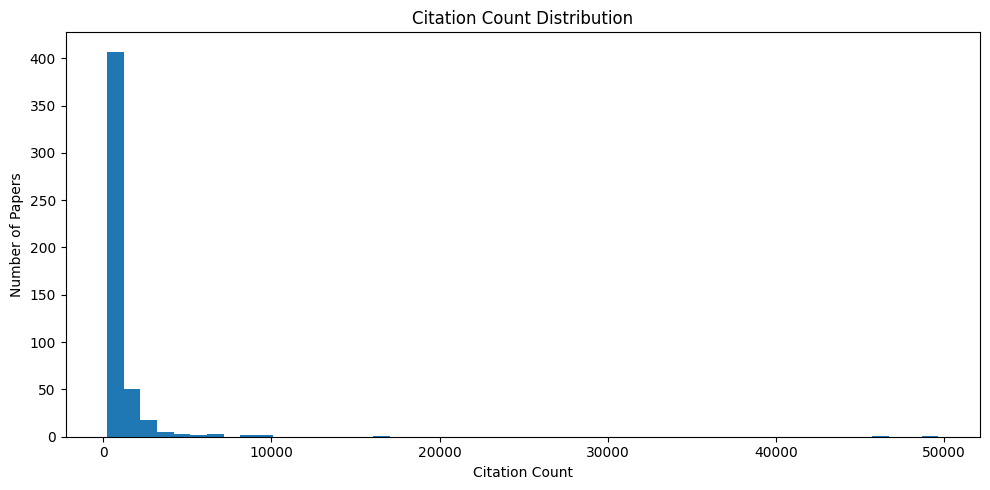

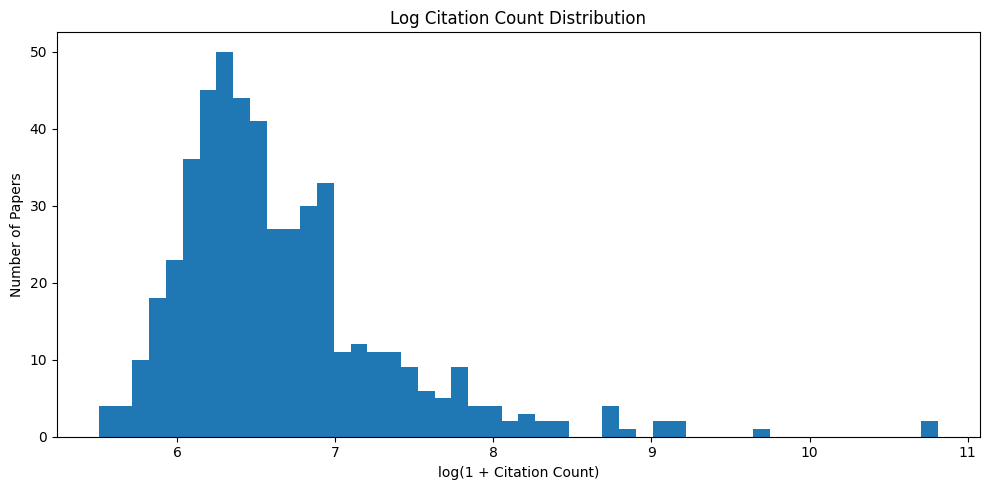

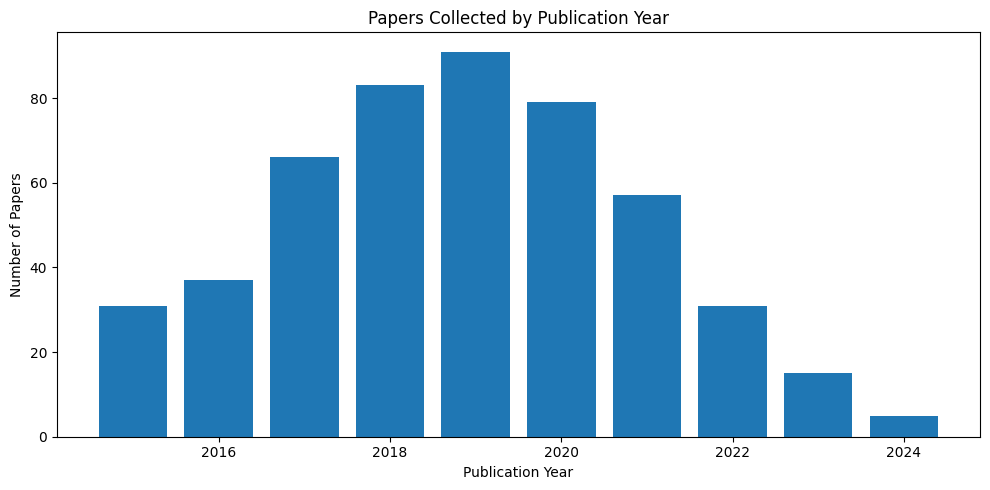

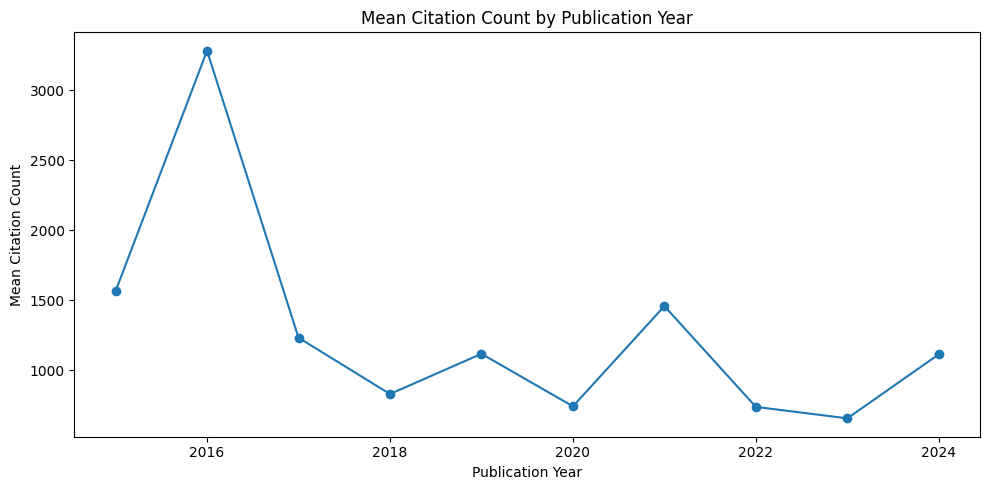

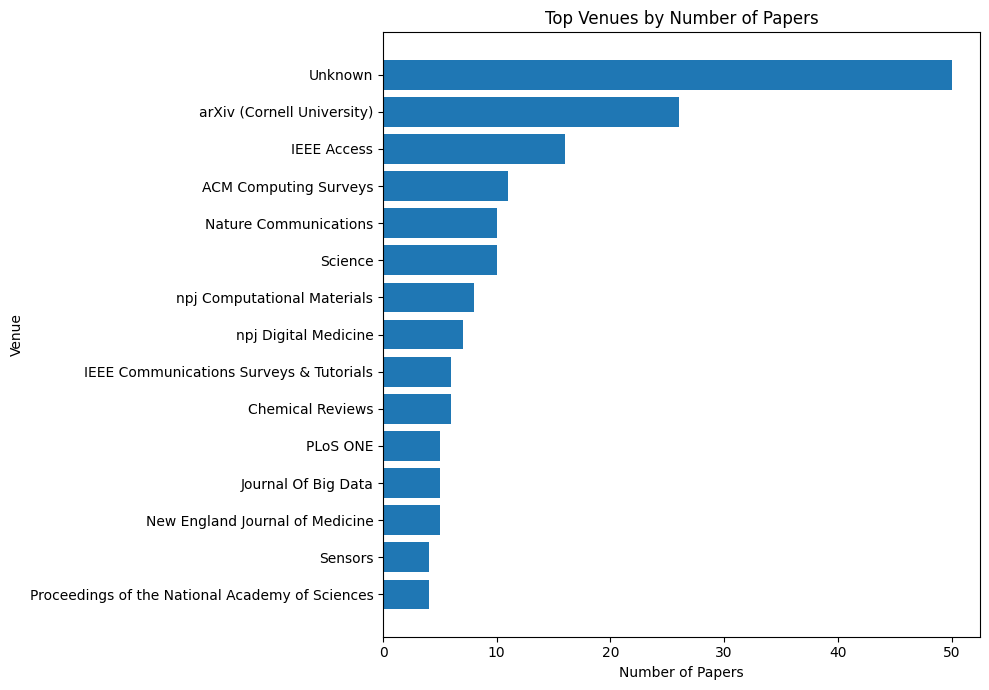

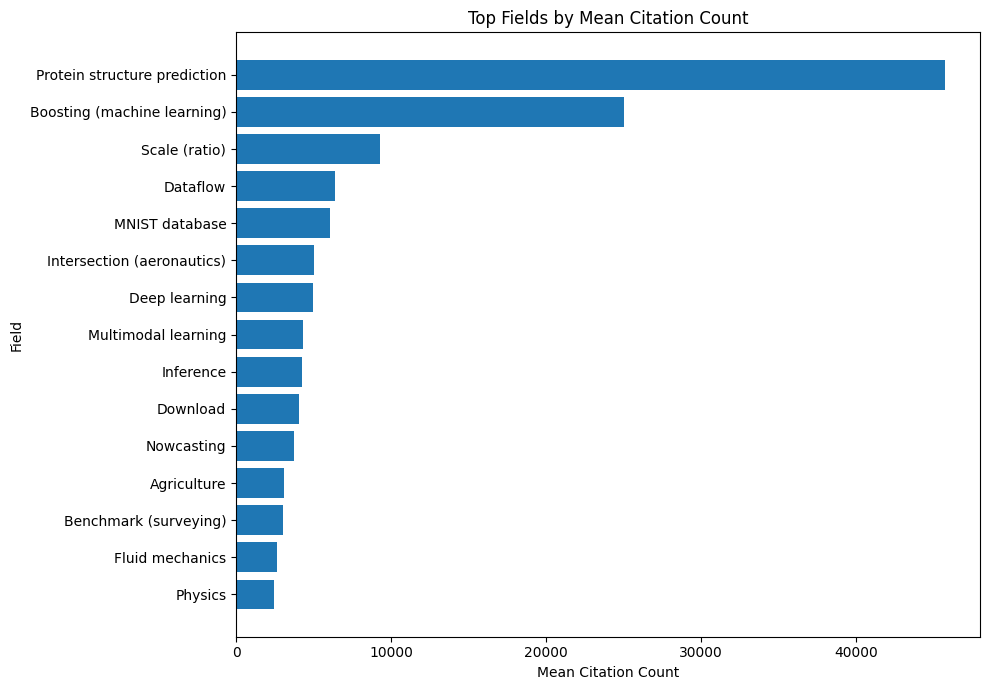


========== DUPLICATE COLUMN CHECK ==========
Duplicate columns: []

========== TRAIN-TEST SPLIT ==========
Time-aware split: train <= 2020, test > 2020
Training rows: 387
Testing rows: 108

Training model: Linear Regression
{'MAE': 2648.535544848256, 'RMSE': 8339.240203131996, 'R2_log_target': -4.819969816711029, 'RMSLE': 1.4232798408205598, 'Model': 'Linear Regression'}

Training model: Ridge Regression
{'MAE': 735.2549617129193, 'RMSE': 4365.070058587221, 'R2_log_target': -0.6873946441410979, 'RMSLE': 0.7663695930609647, 'Model': 'Ridge Regression'}

Training model: Random Forest
{'MAE': 746.3746797333614, 'RMSE': 4336.224628278943, 'R2_log_target': -0.20663012221810795, 'RMSLE': 0.6480626813262553, 'Model': 'Random Forest'}

Training model: Extra Trees
{'MAE': 769.7928866021334, 'RMSE': 4360.296280120225, 'R2_log_target': -0.2808157112734275, 'RMSLE': 0.667687514339953, 'Model': 'Extra Trees'}

Training model: XGBoost
{'MAE': 722.7405372902202, 'RMSE': 4347.781896166045, 'R2_log_ta

,Model,MAE,RMSE,R2_log_target,RMSLE
5,LightGBM,719.672891,4339.535081,-0.161159,0.635734
4,XGBoost,722.740537,4347.781896,-0.172077,0.638716
6,CatBoost,735.349918,4343.113545,-0.183559,0.641837
2,Random Forest,746.374680,4336.224628,-0.206630,0.648063
3,Extra Trees,769.792887,4360.296280,-0.280816,0.667688
1,Ridge Regression,735.254962,4365.070059,-0.687395,0.766370
0,Linear Regression,2648.535545,8339.240203,-4.819970,1.423280


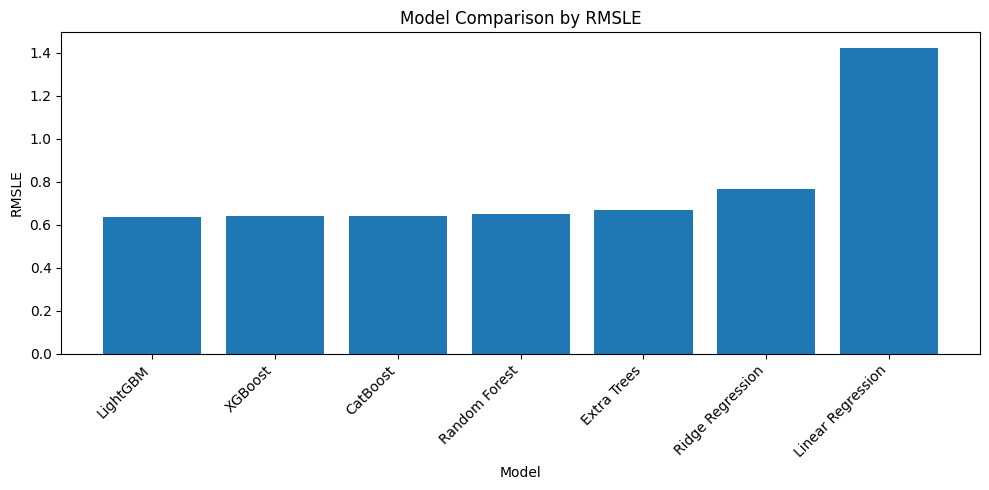

[I 2026-07-16 20:12:03,748] A new study created in memory with name: no-name-1b757d46-d79d-495a-887f-72dc31897010



Best model before tuning: LightGBM

========== OPTUNA TUNING: LIGHTGBM ==========


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-07-16 20:12:04,507] Trial 0 finished with value: 0.6559988345994338 and parameters: {'n_estimators': 267, 'learning_rate': 0.058401052779695775, 'num_leaves': 30, 'max_depth': 11, 'min_child_samples': 10, 'subsample': 0.691619879801167, 'colsample_bytree': 0.6261638709245775}. Best is trial 0 with value: 0.6559988345994338.
[I 2026-07-16 20:12:04,830] Trial 1 finished with value: 0.6682843338500867 and parameters: {'n_estimators': 273, 'learning_rate': 0.08964405445407951, 'num_leaves': 45, 'max_depth': 12, 'min_child_samples': 59, 'subsample': 0.7140239817909646, 'colsample_bytree': 0.8521848349987264}. Best is trial 0 with value: 0.6559988345994338.
[I 2026-07-16 20:12:05,262] Trial 2 finished with value: 0.6121521322738821 and parameters: {'n_estimators': 246, 'learning_rate': 0.031521325615682466, 'num_leaves': 53, 'max_depth': 7, 'min_child_samples': 16, 'subsample': 0.7506864458036469, 'colsample_bytree': 0.9383252890451738}. Best is trial 2 with value: 0.6121521322738821

,paper_title,actual_citations,predicted_citations,prediction_error
473,A Survey on Bias and Fairness in Machine Learning,317.0,844.158675,527.158675
463,Machine Learning for the Diagnosis of Parkinson's Disease: A Review of Literature,382.0,864.542991,482.542991
448,Machine learning in aerodynamic shape optimization,345.0,809.631769,464.631769
411,Machine Learning and the Future of Cardiovascular Care,336.0,800.464206,464.464206
469,Machine Learning for Social Science: An Agnostic Approach,321.0,775.241176,454.241176
472,Machine learning in construction: From shallow to deep learning,311.0,763.070474,452.070474
248,When Machine Learning Meets Privacy,429.0,809.824678,380.824678
196,Machine learning algorithms review,467.0,846.794829,379.794829
357,Machine learning and deep learning—A review for ecologists,419.0,792.260971,373.260971
267,Machine Learning and Deep Learning Applications-A Vision,428.0,799.618937,371.618937



========== MOST UNDERPREDICTED PAPERS ==========


,paper_title,actual_citations,predicted_citations,prediction_error
399,Highly accurate protein structure prediction with AlphaFold,45732.0,811.689208,-44920.310792
13,Machine learning and deep learning,2523.0,671.009675,-1851.990325
66,TRIPOD+AI statement: updated guidance for reporting clinical prediction models that use regression or machine learni...,2422.0,759.465206,-1662.534794
77,Scientific Machine Learning Through Physics–Informed Neural Networks: Where we are and What’s Next,2394.0,823.730825,-1570.269175
72,"CARD 2023: expanded curation, support for machine learning, and resistome prediction at the Comprehensive Antibiotic...",2221.0,707.725336,-1513.274664
58,Classification Based on Decision Tree Algorithm for Machine Learning,1833.0,755.850971,-1077.149029
52,Aleatoric and epistemic uncertainty in machine learning: an introduction to concepts and methods,1514.0,710.771252,-803.228748
67,Machine learning for combinatorial optimization: A methodological tour d'horizon,1357.0,757.220494,-599.779506
130,"Artificial Intelligence and Machine Learning in Clinical Medicine, 2023",1159.0,674.444950,-484.555050
213,Extracting spatial effects from machine learning model using local interpretation method: An example of SHAP and XGB...,1076.0,766.043369,-309.956631



========== FINAL PREDICTION FUNCTION EXAMPLE ==========
Predicted citations: 766.72

========== SUMMARY REPORT ==========


# Citation Prediction Summary Report

**Created by:** Utkarsh Jain
**Data Source:** OpenAlex API

---

## Data Collection


- Data source: OpenAlex API
- Search query: machine learning
- Year range: 2015 to 2025
- Papers collected after cleaning: 495
- Target variable: citation_count
- Modeling target: log1p(citation_count)

## Dataset Summary

| Metric | Value |
|---|---:|
| Number of papers | 495 |
| Number of venues | 262 |
| Number of fields | 196 |
| Mean citation count | 1216.56 |
| Median citation count | 653.00 |
| Maximum citation count | 49653 |
| Mean abstract length | 172.42 |
| Mean number of authors | 5.69 |

## Train-Test Split

Time-aware split: train <= 2020, test > 2020

## Model Comparison

| Model             |      MAE |    RMSE |   R2_log_target |    RMSLE |
|:------------------|---------:|--------:|----------------:|---------:|
| LightGBM          |  719.673 | 4339.54 |       -0.161159 | 0.635734 |
| XGBoost           |  722.741 | 4347.78 |       -0.172077 | 0.638716 |
| CatBoost          |  735.35  | 4343.11 |       -0.183559 | 0.641837 |
| Random Forest     |  746.375 | 4336.22 |       -0.20663  | 0.648063 |
| Extra Trees       |  769.793 | 4360.3  |       -0.280816 | 0.667688 |
| Ridge Regression  |  735.255 | 4365.07 |       -0.687395 | 0.76637  |
| Linear Regression | 2648.54  | 8339.24 |       -4.81997  | 1.42328  |

## Best Model

The best model based on RMSLE is:

**Tuned LightGBM**

Generated on: 2026-07-16 20:12:11



========== FINAL OUTPUT FILES ==========
/content/research_paper_citation_prediction_2015_2025.csv
/content/research_paper_citation_prediction_2015_2025.parquet
/content/research_paper_citation_prediction_summary_report.md
/content/citation_distribution.png
/content/log_citation_distribution.png
/content/papers_by_year.png
/content/mean_citations_by_year.png
/content/top_venues.png
/content/field_wise_citations.png
/content/model_comparison.png
/content/shap_summary.png


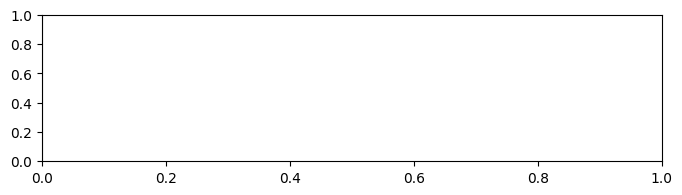

In [17]:
# ============================================================
# 17. Run Full Workflow
# ============================================================

print("Starting research paper citation prediction project.")

raw_df = collect_openalex_papers()

if raw_df.empty:
    raise RuntimeError("No papers collected. Try changing SEARCH_QUERY or year range.")

df = clean_and_engineer_features(raw_df)

if df.empty:
    raise RuntimeError("No valid records after cleaning. Try expanding the query or year range.")

# Save dataset
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
df.to_parquet(OUTPUT_PARQUET, index=False)

print("\nDataset saved:")
print("CSV:", OUTPUT_CSV)
print("Parquet:", OUTPUT_PARQUET)

# EDA
eda = run_eda(df)
show_eda_outputs(df, eda)

# Modeling
X, y, numeric_features, categorical_features, text_feature = prepare_model_data(df)

print("\n========== DUPLICATE COLUMN CHECK ==========")
duplicate_columns = X.columns[X.columns.duplicated()].tolist()
print("Duplicate columns:", duplicate_columns)

# Remove duplicate columns if any still exist
X = X.loc[:, ~X.columns.duplicated()]

preprocessor = create_preprocessor(
    numeric_features,
    categorical_features,
    text_feature
)

X_train, X_test, y_train, y_test, split_type = time_aware_split(df, X, y)

print("\n========== TRAIN-TEST SPLIT ==========")
print(split_type)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

results_df, fitted_pipelines = train_models(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessor
)

print("Created by Utkarsh Jain")
print("Uploaded on Kaggle")


print("\n========== MODEL COMPARISON ==========")
display(results_df)

# Model comparison plot
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSLE"])
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison by RMSLE")
plt.xlabel("Model")
plt.ylabel("RMSLE")
plt.tight_layout()
plt.savefig(PLOT_MODEL_COMPARISON, dpi=300)
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]

print("\nBest model before tuning:", best_model_name)

# Optional tuning for LightGBM
# Runs with limited trials to keep the notebook manageable.
print("\n========== OPTUNA TUNING: LIGHTGBM ==========")

try:
    tuned_lgbm_pipeline, study, tuned_metrics = tune_lightgbm_with_optuna(
        X_train,
        X_test,
        y_train,
        y_test,
        preprocessor,
        n_trials=15
    )

    tuned_rmsle = tuned_metrics["RMSLE"]
    best_rmsle = results_df.iloc[0]["RMSLE"]

    if tuned_rmsle < best_rmsle:
        best_pipeline = tuned_lgbm_pipeline
        best_model_name = "Tuned LightGBM"
        print("Tuned LightGBM selected as final model.")

except Exception as error:
    print("Optuna tuning failed or was skipped.")
    print("Error:", error)

# SHAP Explainability
run_shap_explainability(best_pipeline, X_train, X_test)

# Error Analysis
error_df = run_error_analysis(best_pipeline, X_test, y_test, df)

# Final Prediction Example
example_paper = {
    "paper_title": "A Deep Learning Approach for Efficient Scientific Text Mining",
    "abstract": (
        "This paper proposes a deep learning framework for extracting structured "
        "knowledge from scientific documents using transformer-based representations."
    ),
    "publication_year": 2023,
    "number_of_authors": 4,
    "number_of_institutions": 2,
    "references_count": 45,
    "journal": "Unknown",
    "publisher": "Unknown",
    "field_of_study": "Machine learning",
    "institution": "Unknown",
    "institution_country": "US",
    "source_type": "journal",
    "open_access_status": "gold",
    "open_access": True,
    "international_collaboration": False,
    "keywords": "machine learning; deep learning; text mining"
}

predicted_citations = predict_citations_for_new_paper(best_pipeline, example_paper)

print("\n========== FINAL PREDICTION FUNCTION EXAMPLE ==========")
print("Predicted citations:", round(predicted_citations, 2))

# Summary Report
report_text = create_summary_report(
    df=df,
    results_df=results_df,
    split_type=split_type,
    best_model_name=best_model_name
)

print("\n========== SUMMARY REPORT ==========")
display(Markdown(report_text))

print("\n========== FINAL OUTPUT FILES ==========")

output_files = [
    OUTPUT_CSV,
    OUTPUT_PARQUET,
    SUMMARY_REPORT,
    PLOT_CITATION_DISTRIBUTION,
    PLOT_LOG_CITATION_DISTRIBUTION,
    PLOT_PAPERS_BY_YEAR,
    PLOT_MEAN_CITATIONS_BY_YEAR,
    PLOT_TOP_VENUES,
    PLOT_FIELD_CITATIONS,
    PLOT_MODEL_COMPARISON,
    PLOT_SHAP_SUMMARY
]

for file in output_files:
    print(file)

## 📁 Output Files

The notebook generates the following files:

- `research_paper_citation_prediction_2015_2023.csv`
- `research_paper_citation_prediction_2015_2023.parquet`
- `research_paper_citation_prediction_summary_report.md`
- `citation_distribution.png`
- `log_citation_distribution.png`
- `papers_by_year.png`
- `mean_citations_by_year.png`
- `top_venues.png`
- `field_wise_citations.png`
- `model_comparison.png`
- `shap_summary.png`

These files can be downloaded from the output directory.

> 📥 **Kaggle Tip:** After the notebook finishes, open the output panel to download the datasets, plots, trained model, and summary report.


## 🏁 Conclusion

This notebook demonstrates an end-to-end citation prediction pipeline using open scholarly metadata from OpenAlex.

The project shows that citation prediction can be approached using a combination of bibliographic metadata, authorship features, venue information, open-access indicators, reference counts, and text features extracted from titles and abstracts.

The notebook also highlights the importance of time-aware evaluation because older papers naturally have more time to accumulate citations. By using a time-aware split and log-transformed citation counts, the pipeline provides a more realistic approach to modeling research impact.

Future improvements can include adding Semantic Scholar data, Crossref DOI metadata, journal impact factors, institution rankings, author-level metrics, and sentence-transformer embeddings.

> 🌱 **Next Step:** The pipeline can be extended with author-level indicators, journal metrics, institutional rankings, topic embeddings, and external scholarly data sources.


# 🔗 References

- OpenAlex API Documentation
- OpenAlex API
- Scikit-learn Documentation
- XGBoost Documentation
- LightGBM Documentation
- CatBoost Documentation
- Optuna Documentation
- SHAP Documentation


# 🙏 Thank You for Exploring the Notebook

Found the project useful?

- ⭐ Upvote the notebook
- 💬 Share feedback or suggestions
- 🔄 Fork it for another research field
- 👤 Follow the Kaggle profile for related projects

> 🤝 **Open to collaboration:** Suggestions for stronger features, better evaluation strategies, and new scholarly data sources are welcome.

Happy coding, and happy research! 📚

![GIF](https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExMTI3Nm92YWxxNjNtc214bTdjNjk0dzhzZWlkbThzNXpweG55c3RzZSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/LcdFBvOWyCDoJwtyiR/giphy.gif)
